# 04. UI 추천 전략 검증: 관광지수와 인기도를 왜 분리했는가

## 비즈니스 질문

사용자는 상황에 따라 다른 추천을 원한다.

- “처음 가는 지역에서 알찬 코스”가 필요하면 관광지수 중심이 유리하다.
- “검증된 인기 장소”가 필요하면 인기도 중심이 유리하다.

따라서 UI에서는 `tour_score`와 `review_score`를 분리해 선택하게 했다.


In [1]:
from pathlib import Path
import sys, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# matplotlib 캐시는 이 EDA 폴더 안에만 만들도록 고정한다.
MPL_CACHE_DIR = Path(r'C:/Users/hyunj/Seoul_Strolling_Adventure/Business_Impact_EDA/.matplotlib_cache')
MPL_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE_DIR))

import matplotlib
if 'ipykernel' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Business_Impact_EDA' else Path(r'C:/Users/hyunj/Seoul_Strolling_Adventure')

# 노트북/Colab/로컬 환경에서 한글 폰트가 깨지지 않도록 설정
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
    get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

import os
import shutil
import subprocess
import matplotlib as mpl
from matplotlib import font_manager as fm

# Colab/Linux 계열이면 나눔/Noto CJK 폰트 설치를 시도한다.
# Windows 로컬에서는 apt-get이 없으므로 설치를 건너뛰고 Malgun Gothic을 우선 사용한다.
if shutil.which('apt-get'):
    try:
        subprocess.run(['apt-get', 'update', '-qq'], check=False)
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum', 'fonts-nanum-extra', 'fonts-noto-cjk'],
                       check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except Exception as e:
        print('폰트 설치 단계 건너뜀:', e)

# 캐시 삭제 & 폰트 매니저 재로딩
try:
    shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)
    Path(mpl.get_cachedir()).mkdir(parents=True, exist_ok=True)
    fm._load_fontmanager(try_read_cache=False)
except Exception as e:
    print('폰트 캐시 초기화 단계 건너뜀:', e)

# 우선순위: Colab/Linux용 나눔바른고딕 > 나눔고딕 > Noto CJK > Windows 맑은 고딕
candidates = ['NanumBarunGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Malgun Gothic', 'AppleGothic']
avail = {name: any(name in font.name for font in fm.fontManager.ttflist) for name in candidates}
chosen = next((name for name in candidates if avail.get(name)), 'DejaVu Sans')

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = [chosen]
plt.rcParams['axes.unicode_minus'] = False
print('Using font:', chosen)

def read_csv(path, **kwargs):
    for enc in ['utf-8-sig', 'utf-8', 'cp949']:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, **kwargs)

def find_csv_by_cols(folder, required_cols):
    for p in sorted(Path(folder).rglob('*.csv')):
        try:
            cols = set(read_csv(p, nrows=0).columns)
            if set(required_cols).issubset(cols):
                return p
        except Exception:
            pass
    raise FileNotFoundError(f'{folder} 안에서 컬럼 {required_cols}를 가진 csv를 찾지 못했습니다.')

def pct(a, b):
    if b == 0 or pd.isna(b):
        return np.nan
    return (a - b) / b * 100

DATA = {
    'ui_places': find_csv_by_cols(PROJECT_ROOT / 'UI', ['title', 'tour_score', 'review_score']),
    'congestion': find_csv_by_cols(PROJECT_ROOT / 'UI' / 'congestion_level', ['시간대', 'final_level']),
    'tourism_index': next(PROJECT_ROOT.rglob('final_data_Tourism.csv')),
    'popularity': PROJECT_ROOT / 'EDA' / 'popularity' / 'popularity_result.csv',
    'reviews': PROJECT_ROOT / 'EDA' / 'popularity' / 'zb_review_data_final.csv',
}

print('PROJECT_ROOT =', PROJECT_ROOT)
print('사용 데이터 존재 여부')
for k, v in DATA.items():
    print(f'{k:15s}: {v.exists()} | {v.relative_to(PROJECT_ROOT)}')






Using font: NanumGothic
PROJECT_ROOT = c:\Users\hyunj\Seoul_Strolling_Adventure
사용 데이터 존재 여부
ui_places      : True | UI\관광지_법정동_매핑결과.csv
congestion     : True | UI\congestion_level\혼잡도 최종등급_전국.csv
tourism_index  : True | EDA\관광지수\final_data_Tourism.csv
popularity     : True | EDA\popularity\popularity_result.csv
reviews        : True | EDA\popularity\zb_review_data_final.csv


In [2]:
places = read_csv(DATA['ui_places'])
places['tour_score'] = pd.to_numeric(places['tour_score'], errors='coerce')
places['review_score'] = pd.to_numeric(places['review_score'], errors='coerce')
places = places.dropna(subset=['tour_score','review_score','mapx','mapy'])
places.head()


,title,addr1,tour_score,addr2,areacode,booktour,cat1,cat2,cat3,contentid,...,sigungucode,tel,zipcode,closest_subway_station,closest_subway_line,closest_bus_station,closest_bus_id,법정동,norm_sido,review_score
0,모담 현대백화점킨텍스점,경기도 고양시 일산서구 호수로 817 (대화동),0.999999,8층,31.0,NaN,음식,음식점,한식,3354991,...,2.0,NaN,10391,주엽역,['일산선'],현대백화점,GGB219000625,경기도 고양시 일산서구 대화동,경기도,0.387028
1,장독대김치찜김치찌개_용산점,서울특별시 용산구 한강대로23길 55 (한강로3가),0.966922,테이스티파크 4층,1.0,NaN,음식,음식점,한식,3446973,...,21.0,02-2012-0422,04377,신용산역,['4호선'],용산역,GGB102000161,서울특별시 용산구 한강로3가,서울특별시,0.823988
2,경성한우불고기 송도컨벤시아 본점,인천광역시 연수구 센트럴로 123 송도컨벤시아,0.965591,남문 1층,2.0,NaN,음식,음식점,한식,2913091,...,8.0,NaN,21998,인천대입구역,['인천지하철 1호선'],송도더샵퍼스트월드,ICB164000381,인천광역시 연수구 송도동,인천광역시,0.912708
3,식물학 아이파크몰점,서울특별시 용산구 한강대로23길 55 (한강로3가),0.963142,4층,1.0,NaN,음식,음식점,카페/전통찻집,3443017,...,21.0,02-2012-0434,04377,신용산역,['4호선'],용산역,GGB102000161,서울특별시 용산구 한강로3가,서울특별시,0.796459
4,고든램지버거,서울특별시 송파구 올림픽로 300 롯데월드타워앤드롯데월드몰,0.963126,지하 1층,1.0,NaN,음식,음식점,서양식,2946702,...,18.0,NaN,05551,잠실(송파구청)역,"['2호선', '8호선']",잠실역9번출구,GGB123000046,서울특별시 송파구 신천동,서울특별시,0.561538


In [3]:
places['tour_rank_pct'] = places['tour_score'].rank(pct=True)
places['review_rank_pct'] = places['review_score'].rank(pct=True)
places['strategy_gap'] = places['tour_rank_pct'] - places['review_rank_pct']
places['strategy_type'] = np.select(
    [places['strategy_gap'] >= .35, places['strategy_gap'] <= -.35],
    ['관광자원형', '리뷰검증형'],
    default='균형형'
)
strategy_summary = places.groupby('strategy_type').agg(
    count=('title','size'),
    avg_tour=('tour_score','mean'),
    avg_review=('review_score','mean'),
    subway_coverage=('closest_subway_station', lambda s: s.notna().mean()*100),
    bus_coverage=('closest_bus_station', lambda s: s.notna().mean()*100),
).sort_values('count', ascending=False)
strategy_summary


,count,avg_tour,avg_review,subway_coverage,bus_coverage
strategy_type,,,,,
균형형,21297,0.532442,0.600008,31.070104,93.722120
리뷰검증형,7254,0.437087,0.743551,13.840640,87.951475
관광자원형,7124,0.667490,0.437569,48.512072,97.964627


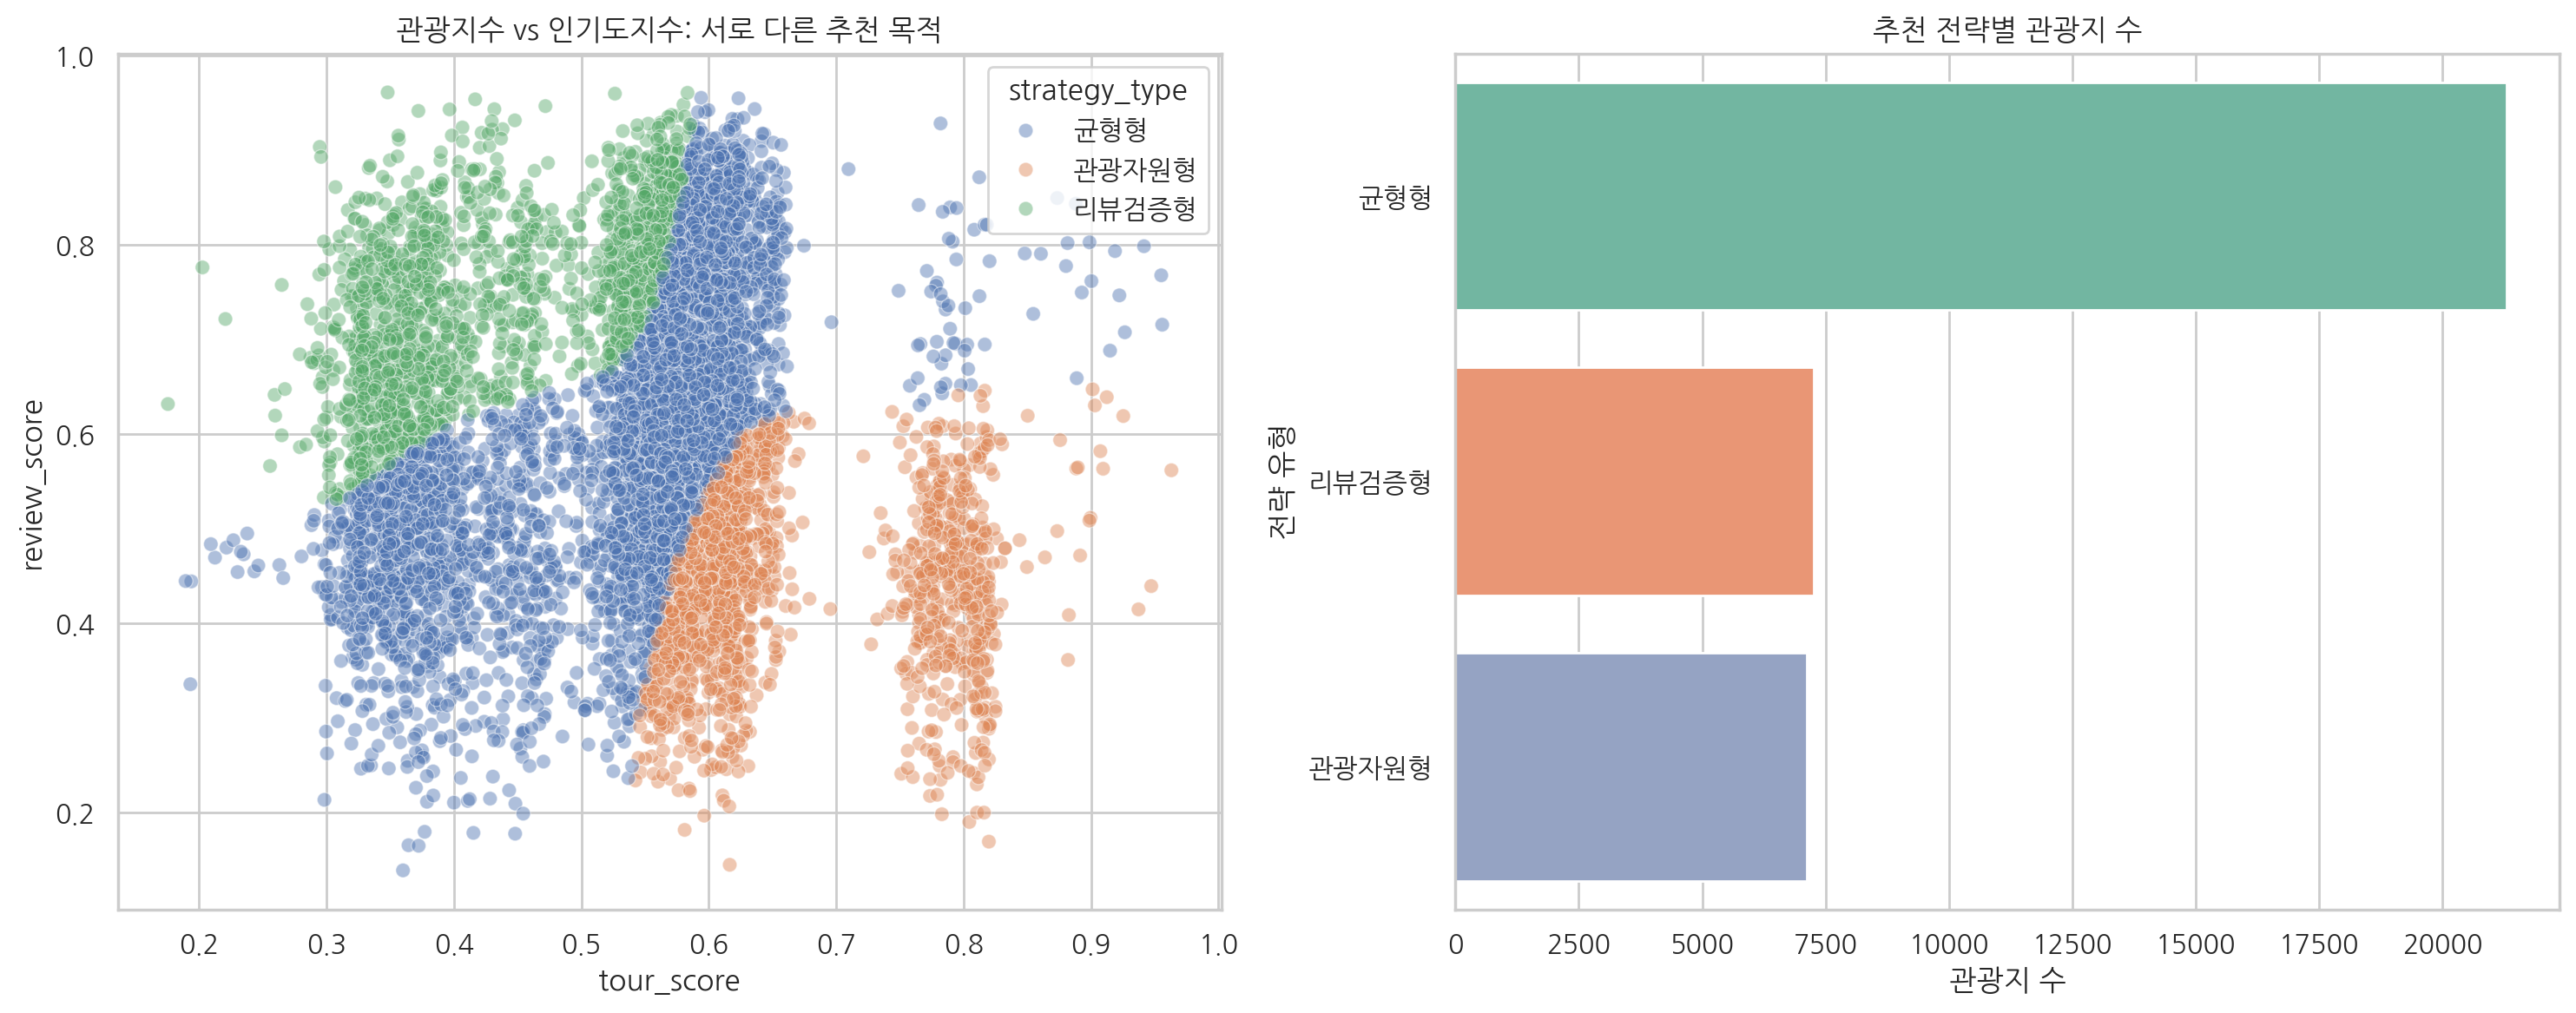

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sample = places.sample(min(8000, len(places)), random_state=42)
sns.scatterplot(data=sample, x='tour_score', y='review_score', hue='strategy_type', alpha=.45, ax=axes[0])
axes[0].set_title('관광지수 vs 인기도지수: 서로 다른 추천 목적')
axes[0].set_xlabel('tour_score')
axes[0].set_ylabel('review_score')
sns.countplot(data=places, y='strategy_type', order=strategy_summary.index, ax=axes[1], palette='Set2')
axes[1].set_title('추천 전략별 관광지 수')
axes[1].set_xlabel('관광지 수')
axes[1].set_ylabel('전략 유형')
plt.tight_layout()
plt.show()


## 모델 검증: 인기도를 관광지 메타데이터로 얼마나 설명할 수 있는가?

여기서 모델의 목적은 예측 서비스가 아니라 **지표 구조가 설명 가능한지 검증**하는 것이다.
`tour_score`, 좌표, 교통 접근성 여부, 카테고리 정보를 사용해 `review_score`를 예측해보고, 설명력이 낮으면 두 지표를 분리해야 한다는 근거가 된다.


In [5]:
model_df = places.copy()
model_df['has_subway'] = model_df['closest_subway_station'].notna().astype(int)
model_df['has_bus'] = model_df['closest_bus_station'].notna().astype(int)
model_df['cat1'] = model_df['cat1'].fillna('unknown').astype(str)
model_df = pd.get_dummies(model_df[['tour_score','mapx','mapy','has_subway','has_bus','cat1','review_score']], columns=['cat1'], drop_first=True)
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()
X = model_df.drop(columns=['review_score'])
y = model_df['review_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
models = {
    'LinearRegression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'RandomForest': RandomForestRegressor(n_estimators=120, random_state=42, min_samples_leaf=5, n_jobs=1),
}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({'model': name, 'MAE': mean_absolute_error(y_test, pred), 'RMSE': mean_squared_error(y_test, pred) ** .5, 'R2': r2_score(y_test, pred)})
result_df = pd.DataFrame(results).sort_values('MAE')
result_df


,model,MAE,RMSE,R2
2,RandomForest,0.107468,0.136207,0.258007
0,LinearRegression,0.123564,0.151846,0.077830
1,Ridge,0.123564,0.151846,0.077831


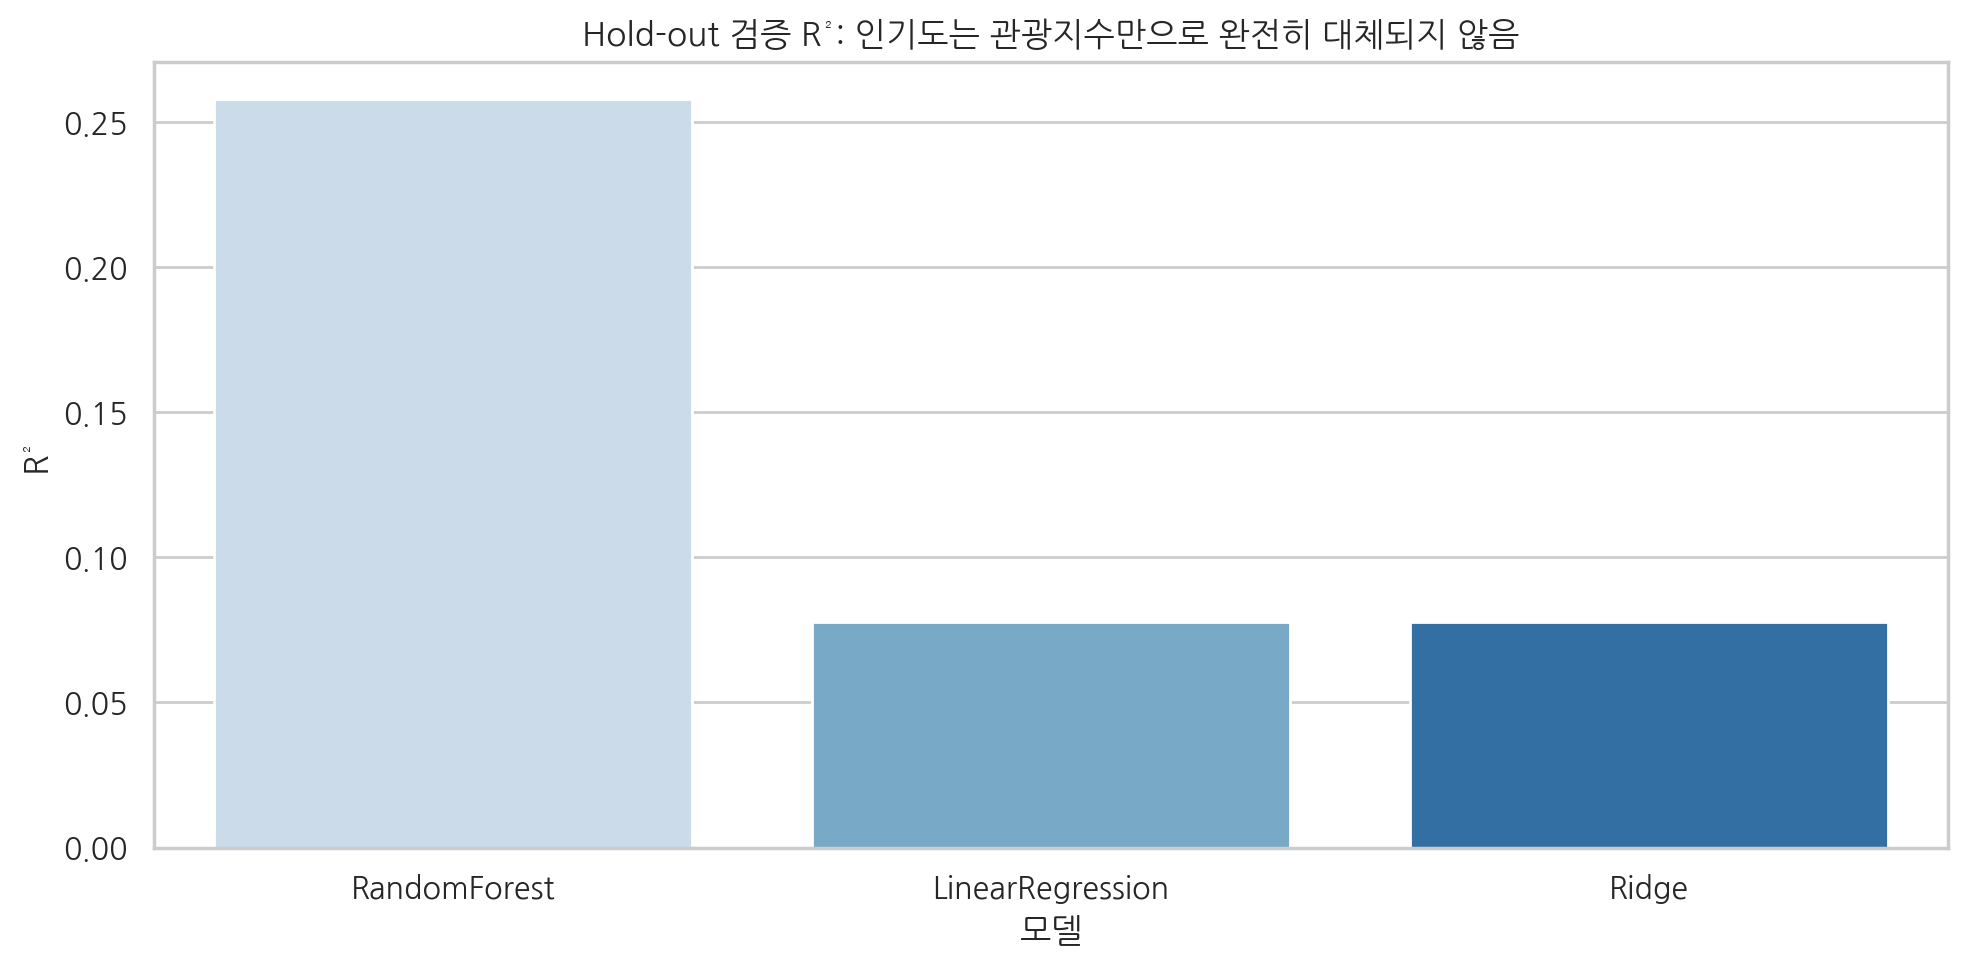

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=result_df, x='model', y='R2', ax=ax, palette='Blues')
ax.set_title('Hold-out 검증 R²: 인기도는 관광지수만으로 완전히 대체되지 않음')
ax.set_xlabel('모델')
ax.set_ylabel('R²')
plt.tight_layout()
plt.show()


In [7]:
best_name = result_df.iloc[0]['model']
best_model = models[best_name]
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='r2')
print(f'최적 모델: {best_name}')
print(f'5-Fold CV R² 평균: {cv_scores.mean():.3f}')
print(f'5-Fold CV R² 표준편차: {cv_scores.std():.3f}')
print('해석: R²가 높지 않으므로 인기도는 관광지수/메타데이터로 완전히 대체되지 않는다. 따라서 UI에서 두 기준을 분리 제공하는 것이 합리적이다.')



최적 모델: RandomForest
5-Fold CV R² 평균: 0.268
5-Fold CV R² 표준편차: 0.014
해석: R²가 높지 않으므로 인기도는 관광지수/메타데이터로 완전히 대체되지 않는다. 따라서 UI에서 두 기준을 분리 제공하는 것이 합리적이다.


## 지수 분리 연결 문장

관광지수와 인기도가 같은 의미라면 UI에서 굳이 분리할 필요가 없다. 그래서 hold-out과 5-fold 교차검증으로 인기도가 관광지 메타데이터만으로 충분히 설명되는지 확인했다. 그 결과 두 지표가 서로 다른 사용자 니즈를 설명한다고 판단했고, UI에서 선택 기준을 분리하는 구조로 보완했다.
